# Multi-view SSL dataset

This notebook shows how to create paired
augmentations for self-supervised learning.

Requirements:
- `torch` and `toyts`
- `matplotlib` for plotting (skip the plotting cell if you do not have it installed)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from toyts.core.pipeline import SynthPipeline
from toyts.core.utils import utils_make_canonical_A0
from toyts.datasets.iterable import SynthBatchIterableDataset
from toyts.kernels.pqrst import make_pqrst_kernel_bank, pqrst_kernel_size
from toyts.processes.pulse_train import PulseTrainProcess
from toyts.views.ecg_leads import ECGLeadsView
from toyts.views.events import EventImpulseView, KernelConvView
from toyts.views.missingness import MissingnessView
from toyts.views.noise import BaselineWanderView, GaussianNoiseView
from toyts.views.units import NormalizeView
from toyts.views.sampling import SamplingAggregationView


## Device setup


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Define the latent process


In [3]:
process = PulseTrainProcess(
    seq_len=1024,
    frequency_hz=1.2,
    sample_rate_hz=250.0,
    rhythm_classes=["regular", "irregular", "missed_beat"],
    shape_classes=["gaussian", "sharp_laplace", "biphasic_dog"],
    latent_mode="pqrst3",
    amplitude=2.0,
)


## Define two augmentation views

Both views share the same latent process, but apply different augmentations.


In [4]:
spacing = (process.seq_len - 1) / (process.num_pulses + 1)
kernel_size = pqrst_kernel_size(spacing=spacing, support_sigma=6.0)
kernels = make_pqrst_kernel_bank(
    shape_names=process.shape_classes,
    spacing=spacing,
    kernel_size=kernel_size,
    device=device,
)  # [K, T, W]
padding = kernel_size // 2

A0 = utils_make_canonical_A0(num_leads=1, num_latent=3)  # [C, K]

def event_head() -> list[torch.nn.Module]:
    return [
        EventImpulseView(
            seq_len=process.seq_len,
            amplitude_param="amplitude",
            rounding="nearest",
        ),
        KernelConvView(kernels=kernels, padding=padding),
    ]

view1_transform = torch.nn.Sequential(
    *event_head(),
    ECGLeadsView(A0=A0, jitter_std=0.05, max_delay=2),
    GaussianNoiseView(noise_std=0.1),
    BaselineWanderView(amplitude_std=0.2, freq_min=0.1, freq_max=0.3),
    SamplingAggregationView(mode="downsample", stride=2),
    NormalizeView(),
)

view2_transform = torch.nn.Sequential(
    *event_head(),
    ECGLeadsView(A0=A0, jitter_std=0.1, max_delay=4),
    GaussianNoiseView(noise_std=0.15),
    BaselineWanderView(amplitude_std=0.4, freq_min=0.05, freq_max=0.2),
    MissingnessView(dropout_prob=0.05, gap_prob=0.1, gap_length=50, hold_prob=0.01),
    NormalizeView(),
)

views = {
    "view1": view1_transform,
    "view2": view2_transform,
}


## Create an iterable dataset

The dataset yields pre-batched pairs of views.


In [5]:
pipeline = SynthPipeline(process=process, views=views)
pipeline.to(device)

dataset = SynthBatchIterableDataset(
    pipeline=pipeline,
    batch_size=4,
    device=device,
    seed=42,
    max_batches=25,
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=None,
    num_workers=0,
)


## Inspect one batch


In [6]:
first_batch = next(iter(dataloader))

view1_obs = first_batch["view1"]
view2_obs = first_batch["view2"]

view1_signal = view1_obs.x  # [B, C, L]
view2_signal = view2_obs.x  # [B, C, L]

view1_shape_labels = view1_obs.y["shape"]  # [B]
view2_shape_labels = view2_obs.y["shape"]  # [B]

print("Dataloader yields batches with keys:", first_batch.keys())

print("\n--- View 1 ---")
print("  Signal shape:", view1_signal.shape)
print("  Shape labels:", view1_shape_labels)

print("\n--- View 2 ---")
print("  Signal shape:", view2_signal.shape)
print("  Shape labels (should match View 1):", view2_shape_labels)

view1_ecg_meta = view1_obs.view_meta("ECGLeadsView")
print("  View 1 ECG delays:", tuple(view1_ecg_meta["delays"].shape))

assert torch.all(view1_obs.y["shape"] == view2_obs.y["shape"])
assert torch.all(view1_obs.y["rhythm"] == view2_obs.y["rhythm"])
print("\nSuccessfully verified that paired views share the same labels.")


Dataloader yields batches with keys: dict_keys(['view1', 'view2'])

--- View 1 ---
  Signal shape: torch.Size([4, 1, 512])
  Shape labels: tensor([1, 2, 1, 0], device='cuda:0')

--- View 2 ---
  Signal shape: torch.Size([4, 1, 1024])
  Shape labels (should match View 1): tensor([1, 2, 1, 0], device='cuda:0')

Successfully verified that paired views share the same labels.


## Plot a paired example

This plots the first sample from each view and saves the figure under `examples/figures`.


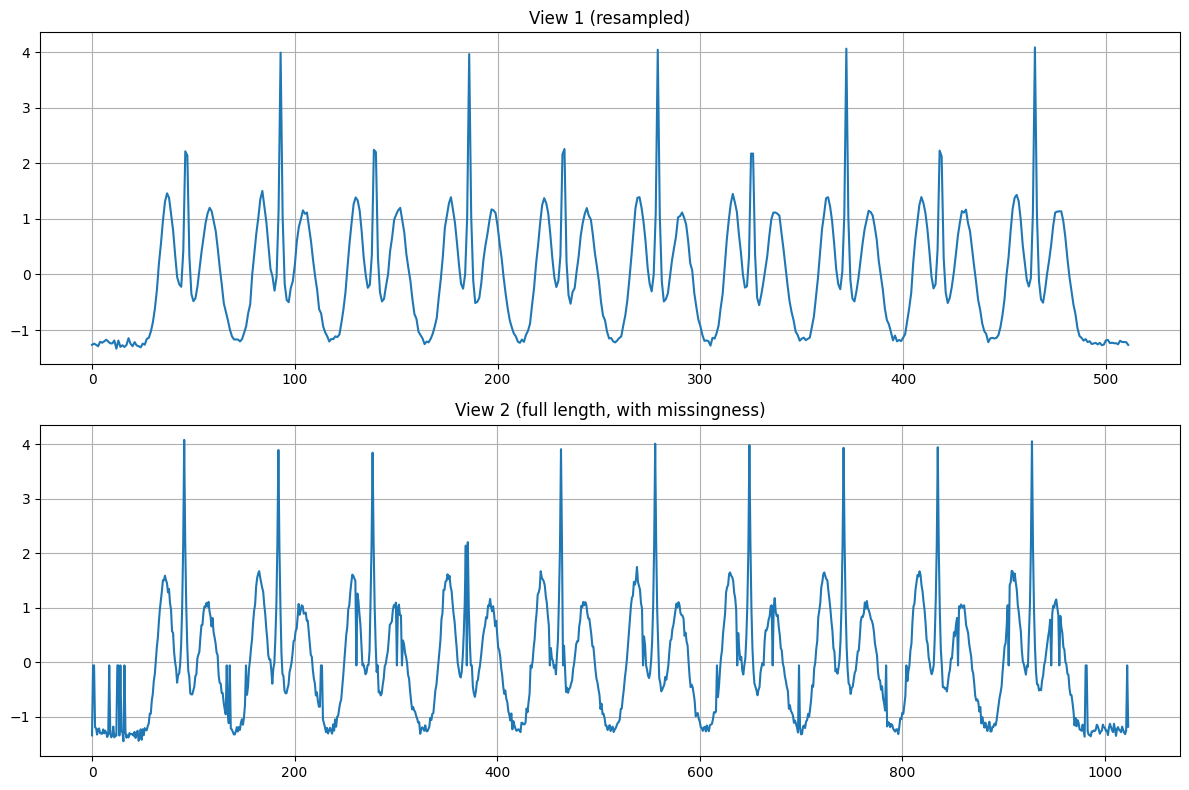

In [8]:
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "02_multiview_ssl.png"

view1_example = view1_signal[0, 0, :].detach().cpu()  # [L]
view2_example = view2_signal[0, 0, :].detach().cpu()  # [L]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
ax1.plot(view1_example.numpy())
ax1.set_title("View 1 (resampled)")
ax1.grid(True)
ax2.plot(view2_example.numpy())
ax2.set_title("View 2 (full length, with missingness)")
ax2.grid(True)
plt.tight_layout()
plt.show()
